# U-Net Baseline (Updated)

This notebook updates the baseline segmentation pipeline with:

- `TverskyLoss` (default `alpha=0.3`, `beta=0.7`) to penalize false positives more strongly.
- Validation threshold optimization by sweeping thresholds from `0.1` to `0.9` and selecting the threshold with max Dice.
- ROC-AUC diagnostics (plus Youden J threshold) as complementary analysis.
- Albumentations-based paired image/mask augmentations for robust medical image training.

In [13]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import albumentations as A
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
 )


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [14]:
# Update these paths for your current environment.
root_data_dir = '/kaggle/input/datasets/sharadprakash117/lung-tumour-baseline-u-net-seg-dataset-filtered/npy_filtered'
train_dir = os.path.join(root_data_dir, 'train')
val_dir = os.path.join(root_data_dir, 'val')
test_dir = os.path.join(root_data_dir, 'test')


class NpyLesionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.file_pairs = []

        for dir_name in os.listdir(root_dir):
            data_dir = os.path.join(root_dir, dir_name, 'data')
            masks_dir = os.path.join(root_dir, dir_name, 'masks')
            if not os.path.isdir(data_dir):
                continue

            for fname in os.listdir(data_dir):
                if fname.endswith('.npy'):
                    self.file_pairs.append(
                        {
                            'image': os.path.join(data_dir, fname),
                            'mask': os.path.join(masks_dir, fname),
                        }
                    )

    def __len__(self):
        return len(self.file_pairs)

    def __getitem__(self, idx):
        pair = self.file_pairs[idx]

        image = np.load(pair['image']).astype(np.float32)
        mask = np.load(pair['mask']).astype(np.float32)
        mask = (mask > 0).astype(np.float32)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        # Convert (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.from_numpy(image), torch.from_numpy(mask)


train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ElasticTransform(alpha=40.0, sigma=5.0, alpha_affine=5.0, p=0.35),
    ]
)

# Keep validation/test deterministic.
val_test_transform = A.Compose([])


train_dataset = NpyLesionDataset(train_dir, transform=train_transform)
val_dataset = NpyLesionDataset(val_dir, transform=val_test_transform)
test_dataset = NpyLesionDataset(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 2868 | Val: 148 | Test: 1335


/tmp/ipykernel_99/2802351458.py:56: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=40.0, sigma=5.0, alpha_affine=5.0, p=0.35),


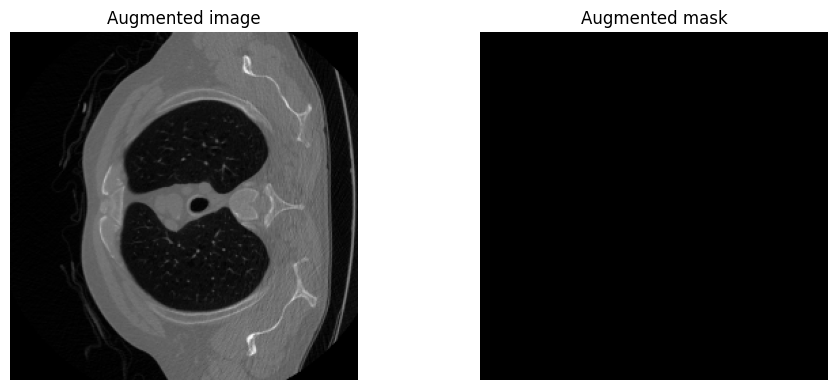

In [15]:
# Quick sanity check for image-mask alignment after augmentation.
batch = next(iter(train_loader))
img = batch[0][0].squeeze().numpy()
mask = batch[1][0].squeeze().numpy()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title('Augmented image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Augmented mask')
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
class BCEDiceLoss(nn.Module):
    def __init__(self, alpha=0.5, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits).view(-1)
        targets_f = targets.view(-1)

        intersection = (probs * targets_f).sum()
        dice_coeff = (2.0 * intersection + self.smooth) / (probs.sum() + targets_f.sum() + self.smooth)
        dice_loss = 1.0 - dice_coeff

        return self.alpha * bce_loss + (1.0 - self.alpha) * dice_loss


class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-6):
        super().__init__()
        self.alpha = alpha  # false negative weight
        self.beta = beta    # false positive weight
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs_f = probs.view(-1)
        targets_f = targets.view(-1)

        tp = (probs_f * targets_f).sum()
        fp = ((1.0 - targets_f) * probs_f).sum()
        fn = (targets_f * (1.0 - probs_f)).sum()

        tversky = (tp + self.smooth) / (tp + self.alpha * fn + self.beta * fp + self.smooth)
        return 1.0 - tversky


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class UNetBaseline(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(128, 64)

        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4)
        x = torch.cat([x3, x], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv_up3(x)

        return self.outc(x)

In [17]:
def dice_score_from_binary(pred_bin, target_bin, smooth=1e-6):
    pred_f = pred_bin.reshape(-1)
    target_f = target_bin.reshape(-1)

    intersection = np.sum(pred_f * target_f)
    return (2.0 * intersection + smooth) / (np.sum(pred_f) + np.sum(target_f) + smooth)


def iou_score_from_binary(pred_bin, target_bin, smooth=1e-6):
    pred_f = pred_bin.reshape(-1)
    target_f = target_bin.reshape(-1)

    intersection = np.sum(pred_f * target_f)
    union = np.sum(pred_f) + np.sum(target_f) - intersection
    return (intersection + smooth) / (union + smooth)


def find_optimal_threshold(val_probs, val_masks, thresholds=None, metric='iou', smooth=1e-6):
    """
    Select a deployment threshold on the full validation set using the same
    global aggregation style used at test time.
    """
    if thresholds is None:
        thresholds = np.round(np.arange(0.1, 1.0, 0.1), 2)

    probs_np = val_probs.detach().cpu().numpy() if torch.is_tensor(val_probs) else np.asarray(val_probs)
    masks_np = val_masks.detach().cpu().numpy() if torch.is_tensor(val_masks) else np.asarray(val_masks)

    masks_np = (masks_np > 0.5).astype(np.float32)
    metric = metric.lower()

    if metric == 'dice':
        score_fn = dice_score_from_binary
    elif metric == 'iou':
        score_fn = iou_score_from_binary
    else:
        raise ValueError(f'Unsupported threshold metric: {metric}')

    threshold_to_score = {}
    best_threshold = float(thresholds[0])
    best_score = -1.0

    for thr in thresholds:
        pred_bin = (probs_np >= thr).astype(np.float32)
        score = score_fn(pred_bin, masks_np, smooth=smooth)
        threshold_to_score[float(thr)] = float(score)
        if score > best_score:
            best_score = float(score)
            best_threshold = float(thr)

    return best_threshold, best_score, threshold_to_score


def compute_roc_diagnostics(val_probs, val_masks):
    """
    Pixel-wise ROC and PR diagnostics for segmentation.
    ROC-AUC and Youden are kept as diagnostics only; PR-based thresholding is
    usually more informative under severe class imbalance.
    """
    probs_np = val_probs.detach().cpu().numpy() if torch.is_tensor(val_probs) else np.asarray(val_probs)
    masks_np = val_masks.detach().cpu().numpy() if torch.is_tensor(val_masks) else np.asarray(val_masks)

    y_score = probs_np.reshape(-1)
    y_true = (masks_np.reshape(-1) > 0.5).astype(np.uint8)

    if np.unique(y_true).size < 2:
        return {
            'roc_auc': None,
            'youden_threshold': None,
            'fpr': None,
            'tpr': None,
            'pr_auc': None,
            'pr_precision': None,
            'pr_recall': None,
            'best_pr_threshold': None,
            'best_pr_f1': None,
        }

    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    youden_j = tpr - fpr
    valid_threshold_mask = np.isfinite(roc_thresholds) & (roc_thresholds >= 0.0) & (roc_thresholds <= 1.0)
    if np.any(valid_threshold_mask):
        valid_indices = np.where(valid_threshold_mask)[0]
        best_youden_idx = valid_indices[int(np.argmax(youden_j[valid_threshold_mask]))]
        youden_threshold = float(roc_thresholds[best_youden_idx])
    else:
        youden_threshold = None

    pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    best_pr_threshold = None
    best_pr_f1 = None
    if pr_thresholds.size > 0:
        precision_for_thr = pr_precision[:-1]
        recall_for_thr = pr_recall[:-1]
        f1_scores = (2.0 * precision_for_thr * recall_for_thr) / (precision_for_thr + recall_for_thr + 1e-8)
        f1_scores = np.nan_to_num(f1_scores, nan=0.0, posinf=0.0, neginf=0.0)
        best_pr_idx = int(np.argmax(f1_scores))
        best_pr_threshold = float(pr_thresholds[best_pr_idx])
        best_pr_f1 = float(f1_scores[best_pr_idx])

    return {
        'roc_auc': float(roc_auc),
        'youden_threshold': youden_threshold,
        'fpr': fpr,
        'tpr': tpr,
        'pr_auc': float(pr_auc),
        'pr_precision': pr_precision,
        'pr_recall': pr_recall,
        'best_pr_threshold': best_pr_threshold,
        'best_pr_f1': best_pr_f1,
    }


def get_detailed_metrics_from_probs(prob_map, target_map, threshold=0.5, smooth=1e-6):
    pred = (prob_map > threshold).float()
    target = target_map.float()

    has_tumor = bool(target.sum() > 0)

    pred_f = pred.view(-1)
    target_f = target.view(-1)

    intersection = (pred_f * target_f).sum()
    dice = (2.0 * intersection + smooth) / (pred_f.sum() + target_f.sum() + smooth)
    iou = (intersection + smooth) / (pred_f.sum() + target_f.sum() - intersection + smooth)
    recall = intersection / (target_f.sum() + smooth) if has_tumor else None

    return {
        'dice': float(dice.item()),
        'iou': float(iou.item()),
        'recall': float(recall.item()) if recall is not None else None,
        'is_positive': has_tumor,
    }


# Thresholding policy in this notebook:
# - Select deployment threshold using validation-set global IoU or Dice.
# - Save that threshold together with the best checkpoint.
# - Keep ROC/Youden as diagnostics; PR-based thresholds are more useful under imbalance.

In [18]:
def build_loss(loss_name='tversky'):
    loss_name = loss_name.lower()
    if loss_name == 'tversky':
        return TverskyLoss(alpha=0.3, beta=0.7)
    if loss_name == 'bce_dice':
        return BCEDiceLoss(alpha=0.5)
    raise ValueError(f'Unsupported loss_name: {loss_name}')


def train_and_validate(
    model,
    train_loader,
    val_loader,
    num_epochs=20,
    loss_name='tversky',
    lr=1e-4,
    threshold_metric='iou',
):
    model.to(device)
    criterion = build_loss(loss_name=loss_name)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    threshold_metric = threshold_metric.lower()
    if threshold_metric not in {'dice', 'iou'}:
        raise ValueError(f'Unsupported threshold_metric: {threshold_metric}')

    best_checkpoint_path = 'baseline_unet_updated_best.pth'
    last_checkpoint_path = 'baseline_unet_updated_last.pth'

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_dice': [],
        'val_dice_all': [],
        'val_dice_pos': [],
        'val_iou_all': [],
        'val_recall_pos': [],
        'val_global_dice': [],
        'val_global_iou': [],
        'best_threshold': [],
        'best_threshold_score': [],
        'roc_auc': [],
        'pr_auc': [],
        'youden_threshold': [],
        'best_pr_threshold': [],
        'best_pr_f1': [],
        'threshold_metric': threshold_metric,
    }

    best_selection_score = -1.0
    best_model_info = {
        'epoch': None,
        'threshold': 0.5,
        'threshold_metric': threshold_metric,
        'selection_score': None,
        'threshold_score': None,
        'roc_auc': None,
        'pr_auc': None,
        'checkpoint_path': best_checkpoint_path,
    }

    for epoch in range(num_epochs):
        model.train()
        train_loss_sum = 0.0
        train_dice_sum = 0.0

        for images, masks in tqdm(train_loader, desc=f'Epoch {epoch + 1} [Train]'):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                pred = (probs > 0.5).float()
                inter = (pred * masks).sum()
                dice_fast = (2.0 * inter + 1e-6) / (pred.sum() + masks.sum() + 1e-6)
                train_dice_sum += dice_fast.item()

        history['train_loss'].append(train_loss_sum / len(train_loader))
        history['train_dice'].append(train_dice_sum / len(train_loader))

        model.eval()
        val_loss_sum = 0.0
        val_prob_batches = []
        val_mask_batches = []

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f'Epoch {epoch + 1} [Val]'):
                images = images.to(device)
                masks = masks.to(device)

                logits = model(images)
                val_loss_sum += criterion(logits, masks).item()

                probs = torch.sigmoid(logits)
                val_prob_batches.append(probs.cpu())
                val_mask_batches.append(masks.cpu())

        val_probs = torch.cat(val_prob_batches, dim=0)
        val_masks = torch.cat(val_mask_batches, dim=0)

        best_thr, best_thr_score, threshold_curve = find_optimal_threshold(
            val_probs,
            val_masks,
            metric=threshold_metric,
        )
        roc_diag = compute_roc_diagnostics(val_probs, val_masks)

        val_probs_np = val_probs.numpy()
        val_masks_np = (val_masks.numpy() > 0.5).astype(np.float32)
        val_preds_np = (val_probs_np >= best_thr).astype(np.float32)

        val_global_dice = dice_score_from_binary(val_preds_np, val_masks_np)
        val_global_iou = iou_score_from_binary(val_preds_np, val_masks_np)

        v_d_all, v_d_pos, v_iou, v_rec = [], [], [], []
        for i in range(val_probs.size(0)):
            m = get_detailed_metrics_from_probs(val_probs[i], val_masks[i], threshold=best_thr)
            v_d_all.append(m['dice'])
            v_iou.append(m['iou'])
            if m['is_positive']:
                v_d_pos.append(m['dice'])
                if m['recall'] is not None:
                    v_rec.append(m['recall'])

        val_dice_all = float(np.mean(v_d_all)) if v_d_all else 0.0

        history['val_loss'].append(val_loss_sum / len(val_loader))
        history['val_dice_all'].append(val_dice_all)
        history['val_iou_all'].append(float(np.mean(v_iou)) if v_iou else 0.0)
        history['val_dice_pos'].append(float(np.mean(v_d_pos)) if v_d_pos else 0.0)
        history['val_recall_pos'].append(float(np.mean(v_rec)) if v_rec else 0.0)
        history['val_global_dice'].append(float(val_global_dice))
        history['val_global_iou'].append(float(val_global_iou))
        history['best_threshold'].append(float(best_thr))
        history['best_threshold_score'].append(float(best_thr_score))
        history['roc_auc'].append(roc_diag['roc_auc'])
        history['pr_auc'].append(roc_diag['pr_auc'])
        history['youden_threshold'].append(roc_diag['youden_threshold'])
        history['best_pr_threshold'].append(roc_diag['best_pr_threshold'])
        history['best_pr_f1'].append(roc_diag['best_pr_f1'])

        selection_score = val_global_dice if threshold_metric == 'dice' else val_global_iou

        if selection_score > best_selection_score:
            best_selection_score = float(selection_score)
            best_model_info = {
                'epoch': epoch + 1,
                'threshold': float(best_thr),
                'threshold_metric': threshold_metric,
                'selection_score': float(selection_score),
                'threshold_score': float(best_thr_score),
                'roc_auc': roc_diag['roc_auc'],
                'pr_auc': roc_diag['pr_auc'],
                'checkpoint_path': best_checkpoint_path,
            }
            torch.save(
                {
                    'model_state_dict': model.state_dict(),
                    'epoch': epoch + 1,
                    'threshold': float(best_thr),
                    'threshold_metric': threshold_metric,
                    'selection_score': float(selection_score),
                    'threshold_score': float(best_thr_score),
                    'roc_auc': roc_diag['roc_auc'],
                    'pr_auc': roc_diag['pr_auc'],
                },
                best_checkpoint_path,
            )

        roc_text = f"{roc_diag['roc_auc']:.4f}" if roc_diag['roc_auc'] is not None else 'N/A'
        pr_text = f"{roc_diag['pr_auc']:.4f}" if roc_diag['pr_auc'] is not None else 'N/A'
        youden_text = f"{roc_diag['youden_threshold']:.4f}" if roc_diag['youden_threshold'] is not None else 'N/A'
        pr_thr_text = f"{roc_diag['best_pr_threshold']:.4f}" if roc_diag['best_pr_threshold'] is not None else 'N/A'

        print(
            f"Epoch {epoch + 1} | "
            f"Val Dice(All): {val_dice_all:.4f} | "
            f"Val Dice(Pos): {history['val_dice_pos'][-1]:.4f} | "
            f"Recall(Pos): {history['val_recall_pos'][-1]:.4f} | "
            f"Global Dice: {val_global_dice:.4f} | "
            f"Global IoU: {val_global_iou:.4f} | "
            f"BestThr({threshold_metric.upper()}): {best_thr:.2f} | "
            f"ROC-AUC: {roc_text} | "
            f"PR-AUC: {pr_text} | "
            f"YoudenThr: {youden_text} | "
            f"PRThr(F1): {pr_thr_text}"
        )

        _ = threshold_curve

    torch.save(model.state_dict(), last_checkpoint_path)

    with open('baseline_history_updated.json', 'w') as f:
        json.dump({
            'history': history,
            'best_model_info': best_model_info,
            'last_checkpoint_path': last_checkpoint_path,
        }, f)

    best_checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    return history, best_model_info

## Why Dice-Threshold + ROC Together?

For highly imbalanced segmentation, pixel-wise ROC-AUC can look good even when false positives are still clinically noisy. A practical approach is:

- Select deployment threshold using **max validation Dice** (directly aligned with segmentation overlap quality).
- Track **ROC-AUC** and **Youden threshold** as supporting diagnostics.

This notebook follows that policy.

In [19]:
model = UNetBaseline().to(device)
history, best_model_info = train_and_validate(
    model,
    train_loader,
    val_loader,
    num_epochs=20,
    loss_name='tversky',
    lr=1e-4,
    threshold_metric='iou',
)

print(
    f"Selected checkpoint: epoch {best_model_info['epoch']} | "
    f"threshold ({best_model_info['threshold_metric'].upper()}): {best_model_info['threshold']:.2f} | "
    f"score: {best_model_info['selection_score']:.4f}"
)

Epoch 1 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 | Val Dice(All): 0.2754 | Val Dice(Pos): 0.1995 | Recall(Pos): 0.2398 | Global Dice: 0.1224 | Global IoU: 0.0652 | BestThr(IOU): 0.90 | ROC-AUC: 0.8829 | PR-AUC: 0.0377 | YoudenThr: 0.1991 | PRThr(F1): 0.9683


Epoch 2 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 2 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

...

Epoch 19 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 19 | Val Dice(All): 0.6308 | Val Dice(Pos): 0.4508 | Recall(Pos): 0.4554 | Global Dice: 0.6251 | Global IoU: 0.4547 | BestThr(IOU): 0.10 | ROC-AUC: 0.9103 | PR-AUC: 0.5460 | YoudenThr: 0.0001 | PRThr(F1): 0.0861


Epoch 20 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 20 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 20 | Val Dice(All): 0.6227 | Val Dice(Pos): 0.5021 | Recall(Pos): 0.5090 | Global Dice: 0.6888 | Global IoU: 0.5253 | BestThr(IOU): 0.50 | ROC-AUC: 0.9354 | PR-AUC: 0.6524 | YoudenThr: 0.0001 | PRThr(F1): 0.7655
Selected checkpoint: epoch 20 | threshold (IOU): 0.50 | score: 0.5253


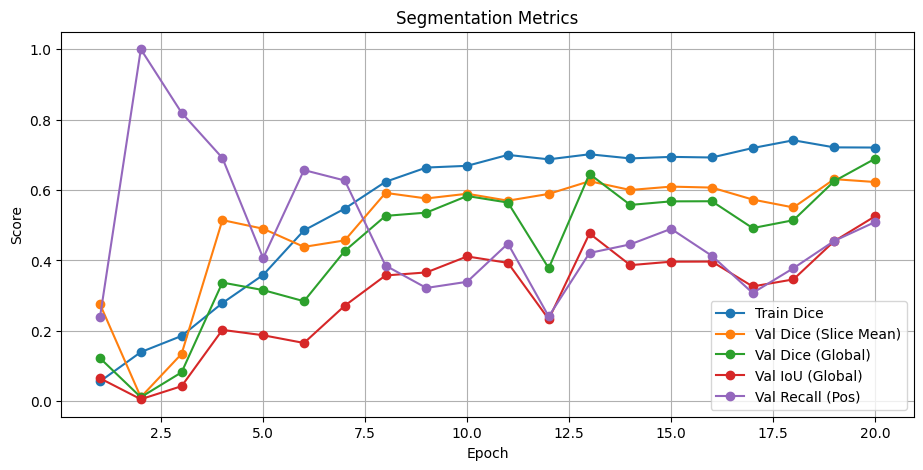

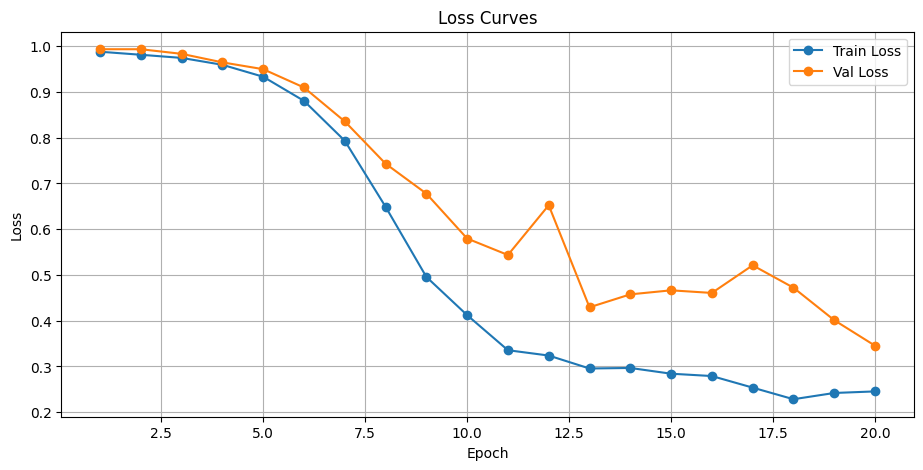

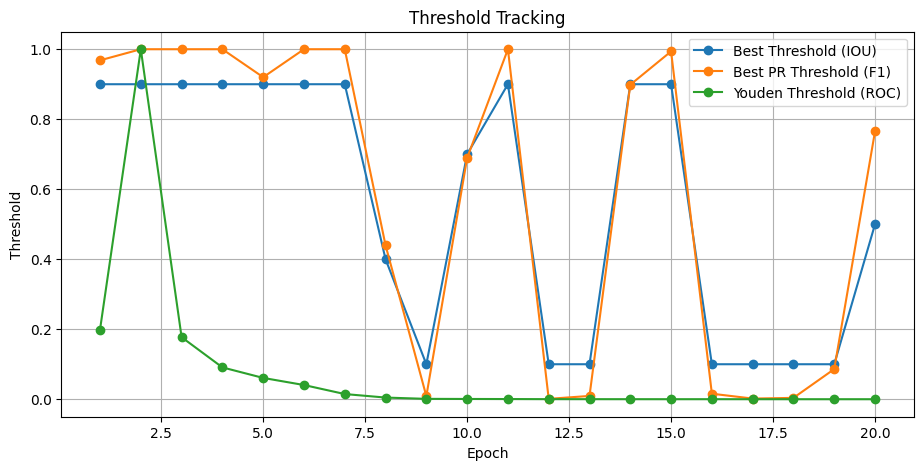

In [20]:
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(11, 5))
plt.plot(epochs, history['train_dice'], marker='o', label='Train Dice')
plt.plot(epochs, history['val_dice_all'], marker='o', label='Val Dice (Slice Mean)')
plt.plot(epochs, history['val_global_dice'], marker='o', label='Val Dice (Global)')
plt.plot(epochs, history['val_global_iou'], marker='o', label='Val IoU (Global)')
plt.plot(epochs, history['val_recall_pos'], marker='o', label='Val Recall (Pos)')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Segmentation Metrics')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
plt.plot(epochs, history['val_loss'], marker='o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(epochs, history['best_threshold'], marker='o', label=f"Best Threshold ({history['threshold_metric'].upper()})")
plt.plot(epochs, [t if t is not None else np.nan for t in history['best_pr_threshold']], marker='o', label='Best PR Threshold (F1)')
plt.plot(epochs, [t if t is not None else np.nan for t in history['youden_threshold']], marker='o', label='Youden Threshold (ROC)')
plt.xlabel('Epoch')
plt.ylabel('Threshold')
plt.title('Threshold Tracking')
plt.grid(True)
plt.legend()
plt.show()

In [21]:
def evaluate_and_visualize_test(model, test_loader, save_path, threshold=0.5):
    model.to(device)
    model.eval()
    os.makedirs(save_path, exist_ok=True)

    total_inter = 0.0
    total_mask_pix = 0.0
    total_pred_pix = 0.0

    total_pos_slices = 0
    detected_pos_slices = 0

    smooth = 1e-6

    with torch.no_grad():
        for i, (images, masks) in enumerate(tqdm(test_loader, desc='Testing & Visualizing')):
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            preds_f = preds.view(-1)
            masks_f = masks.view(-1)

            total_inter += (preds_f * masks_f).sum().item()
            total_mask_pix += masks_f.sum().item()
            total_pred_pix += preds_f.sum().item()

            for b in range(images.size(0)):
                img_np = images[b, 0].cpu().numpy()
                gt_np = masks[b, 0].cpu().numpy()
                pred_np = preds[b, 0].cpu().numpy()

                has_gt = gt_np.max() > 0
                has_pred = pred_np.max() > 0

                inter_s = (pred_np * gt_np).sum()
                union_s = pred_np.sum() + gt_np.sum() - inter_s
                dice_s = (2.0 * inter_s + smooth) / (pred_np.sum() + gt_np.sum() + smooth)
                iou_s = (inter_s + smooth) / (union_s + smooth)

                if has_gt:
                    total_pos_slices += 1
                    if inter_s > 0:
                        detected_pos_slices += 1

                if has_gt or has_pred:
                    fig, ax = plt.subplots(1, 2, figsize=(14, 7))

                    ax[0].imshow(img_np, cmap='gray')
                    ax[0].set_title('Original CT Scan')
                    ax[0].axis('off')

                    overlay = np.stack([img_np] * 3, axis=-1)
                    overlay[gt_np > 0] = [0, 1, 0]
                    overlay[pred_np > 0] = [1, 0, 0]

                    ax[1].imshow(overlay)
                    ax[1].set_title(f'GT: Green | Pred: Red\nDice: {dice_s:.4f} | IoU: {iou_s:.4f}')
                    ax[1].axis('off')

                    plt.tight_layout()
                    plt.savefig(os.path.join(save_path, f'result_b{i}_s{b}.png'), dpi=150)
                    plt.close()

    global_dice = (2.0 * total_inter + smooth) / (total_mask_pix + total_pred_pix + smooth)
    global_iou = (total_inter + smooth) / (total_mask_pix + total_pred_pix - total_inter + smooth)
    recall_rate = detected_pos_slices / (total_pos_slices + smooth)

    metrics = {
        'global_dice': float(global_dice),
        'global_iou': float(global_iou),
        'recall_rate': float(recall_rate),
        'total_tumor_slices': int(total_pos_slices),
        'detected_tumor_slices': int(detected_pos_slices),
        'threshold_used': float(threshold),
    }

    print(f"\nGlobal Dice: {global_dice:.4f} | Global IoU: {global_iou:.4f}")
    print(f"Recall: {recall_rate:.4f} ({detected_pos_slices}/{total_pos_slices})")
    print(f"Threshold used: {threshold:.2f}")

    return metrics


checkpoint = torch.load('baseline_unet_updated_best.pth', map_location=device)
model = UNetBaseline().to(device)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    threshold_for_test = float(checkpoint.get('threshold', 0.5))
    checkpoint_epoch = checkpoint.get('epoch', 'N/A')
    checkpoint_metric = checkpoint.get('threshold_metric', 'iou').upper()
else:
    model.load_state_dict(checkpoint)
    threshold_for_test = float(best_model_info['threshold']) if 'best_model_info' in globals() else 0.5
    checkpoint_epoch = 'N/A'
    checkpoint_metric = best_model_info['threshold_metric'].upper() if 'best_model_info' in globals() else 'IOU'

model.eval()
print(
    f"Loaded best checkpoint: epoch {checkpoint_epoch} | "
    f"threshold ({checkpoint_metric}): {threshold_for_test:.2f}"
)

test_stats = evaluate_and_visualize_test(
    model,
    test_loader,
    save_path='/kaggle/working/baseline_test_set_outputs_updated',
    threshold=threshold_for_test,
 )

print(test_stats)

Loaded best checkpoint: epoch 20 | threshold (IOU): 0.50


Testing & Visualizing:   0%|          | 0/84 [00:00<?, ?it/s]


Global Dice: 0.5102 | Global IoU: 0.3424
Recall: 0.5842 (59/101)
Threshold used: 0.50
{'global_dice': 0.5101819287260569, 'global_iou': 0.3424457915981321, 'recall_rate': 0.5841584100578375, 'total_tumor_slices': 101, 'detected_tumor_slices': 59, 'threshold_used': 0.5}


In [26]:
def evaluate_test_metrics_only(model, test_loader, thresholds=None):
    """
    Sweep thresholds on the test set and return per-threshold global metrics.
    No images are saved.
    """
    if thresholds is None:
        thresholds = np.round(np.arange(0.01, 0.5, 0.01), 2)

    model.to(device)
    model.eval()
    smooth = 1e-6

    # Collect all probabilities and masks in one pass.
    all_probs_batches = []
    all_masks_batches = []

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc='Collecting test probabilities'):
            images = images.to(device)
            logits = model(images)
            probs = torch.sigmoid(logits).cpu()
            all_probs_batches.append(probs)
            all_masks_batches.append(masks.cpu())

    all_probs = torch.cat(all_probs_batches, dim=0).numpy()
    all_masks = (torch.cat(all_masks_batches, dim=0).numpy() > 0.5).astype(np.float32)

    results = []
    for thr in thresholds:
        preds = (all_probs >= thr).astype(np.float32)
        preds_f = preds.reshape(-1)
        masks_f = all_masks.reshape(-1)

        total_inter = np.sum(preds_f * masks_f)
        total_pred  = np.sum(preds_f)
        total_mask  = np.sum(masks_f)

        global_dice = (2.0 * total_inter + smooth) / (total_pred + total_mask + smooth)
        global_iou  = (total_inter + smooth) / (total_pred + total_mask - total_inter + smooth)

        # Recall: per positive slice, then averaged.
        n_slices = all_probs.shape[0]
        total_pos = 0
        detected_pos = 0
        recall_sum = 0.0
        precision_sum = 0.0
        dice_pos_sum = 0.0
        n_pos_slices = 0

        for i in range(n_slices):
            gt   = all_masks[i].reshape(-1)
            pred = preds[i].reshape(-1)
            has_gt = gt.sum() > 0

            if has_gt:
                total_pos += 1
                tp = np.sum(pred * gt)
                if tp > 0:
                    detected_pos += 1
                recall_sum   += tp / (gt.sum() + smooth)
                precision_sum += tp / (pred.sum() + smooth)
                dice_pos_sum  += (2.0 * tp + smooth) / (pred.sum() + gt.sum() + smooth)
                n_pos_slices  += 1

        recall_pos = recall_sum / (n_pos_slices + smooth)
        precision_pos = precision_sum / (n_pos_slices + smooth)
        dice_pos = dice_pos_sum / (n_pos_slices + smooth)
        detection_rate = detected_pos / (total_pos + smooth)

        results.append({
            'threshold': float(thr),
            'global_dice': float(global_dice),
            'global_iou': float(global_iou),
            'dice_pos_slices': float(dice_pos),
            'recall_pos': float(recall_pos),
            'precision_pos': float(precision_pos),
            'detection_rate': float(detection_rate),
            'detected': int(detected_pos),
            'total_pos': int(total_pos),
        })

    return results


threshold_sweep_results = evaluate_test_metrics_only(model, test_loader)

print(f"{'Thr':>5}  {'G-Dice':>8}  {'G-IoU':>8}  {'Dice(Pos)':>10}  {'Recall(Pos)':>12}  {'Prec(Pos)':>10}  {'Detect':>8}")
print('-' * 75)
for r in threshold_sweep_results:
    print(
        f"{r['threshold']:>5.2f}  "
        f"{r['global_dice']:>8.4f}  "
        f"{r['global_iou']:>8.4f}  "
        f"{r['dice_pos_slices']:>10.4f}  "
        f"{r['recall_pos']:>12.4f}  "
        f"{r['precision_pos']:>10.4f}  "
        f"{r['detected']:>3d}/{r['total_pos']:<3d}"
    )

best_iou_result = max(threshold_sweep_results, key=lambda x: x['global_iou'])
best_dice_result = max(threshold_sweep_results, key=lambda x: x['global_dice'])
print(f"\nBest Global IoU  -> threshold={best_iou_result['threshold']:.2f}  IoU={best_iou_result['global_iou']:.4f}  Dice={best_iou_result['global_dice']:.4f}")
print(f"Best Global Dice -> threshold={best_dice_result['threshold']:.2f}  Dice={best_dice_result['global_dice']:.4f}  IoU={best_dice_result['global_iou']:.4f}")

  Thr    G-Dice     G-IoU   Dice(Pos)   Recall(Pos)   Prec(Pos)    Detect
---------------------------------------------------------------------------
 0.01    0.5110    0.3432      0.4305        0.4435      0.5125   64/101
 0.02    0.5127    0.3447      0.4258        0.4349      0.4895   61/101
 0.03    0.5130    0.3450      0.4238        0.4303      0.4922   61/101
 0.04    0.5131    0.3450      0.4215        0.4260      0.4949   61/101
 0.05    0.5128    0.3448      0.4202        0.4227      0.4965   61/101
 0.06    0.5134    0.3454      0.4192        0.4205      0.4979   61/101
 0.07    0.5136    0.3455      0.4183        0.4187      0.4990   61/101
 0.08    0.5137    0.3456      0.4177        0.4177      0.4996   61/101
 0.09    0.5138    0.3457      0.4175        0.4170      0.5003   61/101
 0.10    0.5137    0.3456      0.4167        0.4160      0.5008   61/101
 0.11    0.5135    0.3455      0.4160        0.4148      0.5013   61/101
 0.12    0.5136    0.3455      0.4152        0.

## Additional Visualizations for Kaggle Runs

These plots provide richer monitoring on top of the current training and test metrics:

- Validation ROC-AUC trend across epochs.
- Final validation Dice-vs-threshold sweep.
- Final validation ROC curve.
- Inline preview of saved qualitative test overlays.

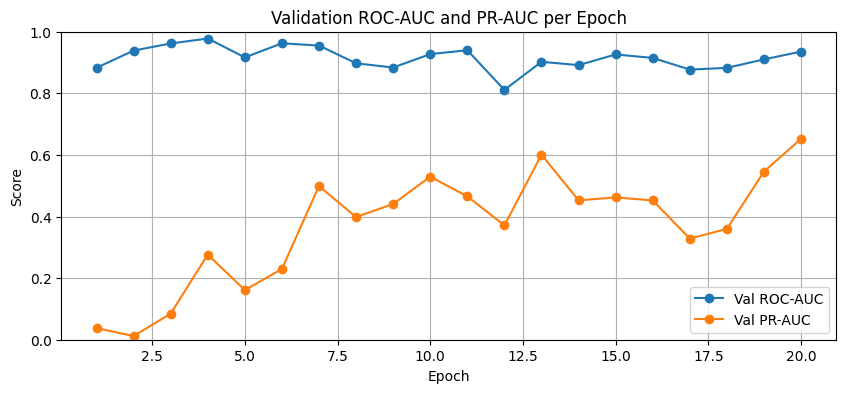

In [22]:
roc_vals = [v if v is not None else np.nan for v in history['roc_auc']]
pr_vals = [v if v is not None else np.nan for v in history['pr_auc']]

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(roc_vals) + 1), roc_vals, marker='o', label='Val ROC-AUC')
plt.plot(range(1, len(pr_vals) + 1), pr_vals, marker='o', label='Val PR-AUC')
plt.title('Validation ROC-AUC and PR-AUC per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.ylim(0.0, 1.0)
plt.grid(True)
plt.legend()
plt.show()

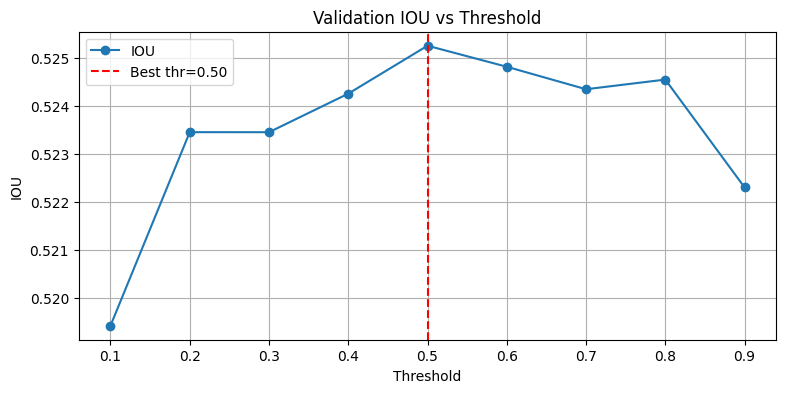

Best threshold from sweep (IOU): 0.50 | Score: 0.5253


In [23]:
model.eval()
val_prob_batches = []
val_mask_batches = []
threshold_metric = history['threshold_metric'] if isinstance(history, dict) else 'iou'

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc='Collecting validation probabilities'):
        images = images.to(device)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu()
        val_prob_batches.append(probs)
        val_mask_batches.append(masks.cpu())

val_probs = torch.cat(val_prob_batches, dim=0)
val_masks = torch.cat(val_mask_batches, dim=0)

best_thr_eval, best_score_eval, thr_to_score = find_optimal_threshold(
    val_probs,
    val_masks,
    metric=threshold_metric,
 )

x_thr = list(thr_to_score.keys())
y_score = list(thr_to_score.values())

plt.figure(figsize=(9, 4))
plt.plot(x_thr, y_score, marker='o', label=threshold_metric.upper())
plt.axvline(best_thr_eval, color='red', linestyle='--', label=f'Best thr={best_thr_eval:.2f}')
plt.title(f'Validation {threshold_metric.upper()} vs Threshold')
plt.xlabel('Threshold')
plt.ylabel(threshold_metric.upper())
plt.grid(True)
plt.legend()
plt.show()

print(f"Best threshold from sweep ({threshold_metric.upper()}): {best_thr_eval:.2f} | Score: {best_score_eval:.4f}")

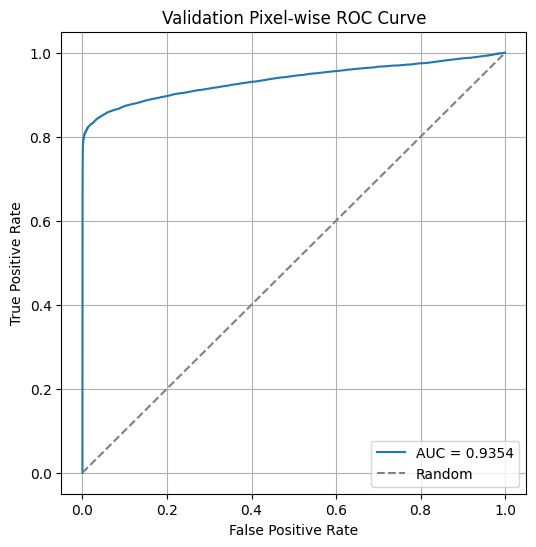

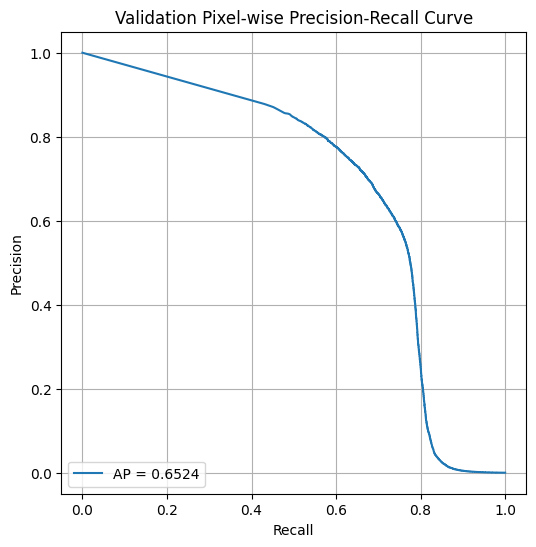

Youden threshold (diagnostic only): 0.0001
Best PR threshold (F1 diagnostic): 0.7655 | F1: 0.6890


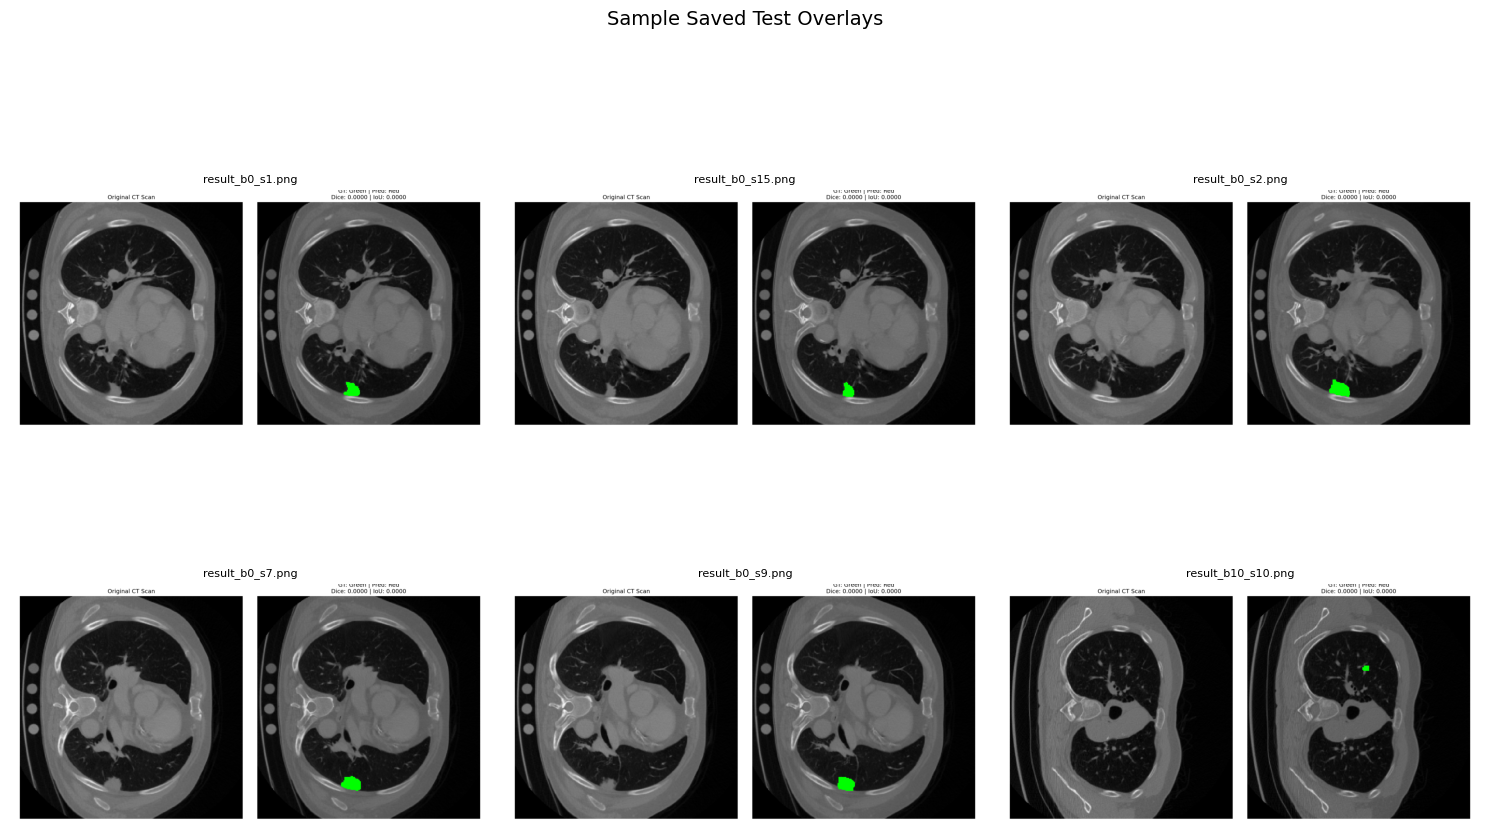

In [24]:
roc_diag_eval = compute_roc_diagnostics(val_probs, val_masks)

if roc_diag_eval['fpr'] is not None:
    plt.figure(figsize=(6, 6))
    plt.plot(roc_diag_eval['fpr'], roc_diag_eval['tpr'], label=f"AUC = {roc_diag_eval['roc_auc']:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.title('Validation Pixel-wise ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.grid(True)
    plt.legend(loc='lower right')
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.plot(roc_diag_eval['pr_recall'], roc_diag_eval['pr_precision'], label=f"AP = {roc_diag_eval['pr_auc']:.4f}")
    plt.title('Validation Pixel-wise Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid(True)
    plt.legend(loc='lower left')
    plt.show()

    youden_text = f"{roc_diag_eval['youden_threshold']:.4f}" if roc_diag_eval['youden_threshold'] is not None else 'N/A'
    pr_thr_text = f"{roc_diag_eval['best_pr_threshold']:.4f}" if roc_diag_eval['best_pr_threshold'] is not None else 'N/A'
    pr_f1_text = f"{roc_diag_eval['best_pr_f1']:.4f}" if roc_diag_eval['best_pr_f1'] is not None else 'N/A'

    print(f"Youden threshold (diagnostic only): {youden_text}")
    print(f"Best PR threshold (F1 diagnostic): {pr_thr_text} | F1: {pr_f1_text}")
else:
    print('ROC/PR curves are not available: validation masks contain only one class.')


preview_dir = '/kaggle/working/baseline_test_set_outputs_updated'
if os.path.isdir(preview_dir):
    preview_files = sorted(
        [f for f in os.listdir(preview_dir) if f.lower().endswith('.png')]
    )

    n_show = min(6, len(preview_files))
    if n_show == 0:
        print(f'No PNG overlays found in {preview_dir}')
    else:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        for i in range(6):
            axes[i].axis('off')

        for i in range(n_show):
            img_path = os.path.join(preview_dir, preview_files[i])
            axes[i].imshow(plt.imread(img_path))
            axes[i].set_title(preview_files[i], fontsize=8)
            axes[i].axis('off')

        plt.suptitle('Sample Saved Test Overlays', fontsize=14)
        plt.tight_layout()
        plt.show()
else:
    print(f'Preview directory not found: {preview_dir}')